In [1]:
# Core stack ----------------------------------------------------------------
# Deep learning uses PyTorch; feature ranking and baselines use scikit-learn.
# The project's src/ package provides data loading, feature engineering,
# modelling, training and prediction utilities.

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import sys, json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from IPython.display import display, Image, Markdown
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.preprocessing import StandardScaler

# --- Project path setup ----------------------------------------------------
ROOT = next((p for p in (Path.cwd(), Path.cwd().parent)
             if (p / "src/train.py").exists()), None)
if ROOT is None:
    raise FileNotFoundError(
        "Open this notebook inside the cloned energy_forecasting repository.")
sys.path.insert(0, str(ROOT))

from src.data_preprocessing import (load_data, split_boundaries,
                                     audit_data, fit_feature_preprocessing)
from src.feature_engineering import (choose_lags, make_features,
                                      select_features, MAX_LAG, WARMUP)
from src.model import EnergyRNN, SequenceDataset
from src.train import run_pipeline
from src.predict import forecast_next

# --- Constants -------------------------------------------------------------
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
RUN_TRAINING = False          # set True to retrain in a rerun/ directory
RESULT_ROOT = ROOT / "rerun" if RUN_TRAINING else ROOT
DATA_PATH = ROOT / "data/raw/energy_data_set.csv"
TARGET = "Appliances"
FREQ = "10min"
STEPS_PER_HOUR, STEPS_PER_DAY = 6, 144

mpl.rcParams.update({"figure.figsize": (12, 4), "axes.grid": True,
                     "grid.alpha": 0.3, "figure.dpi": 110, "font.size": 10})
sns.set_theme(style="whitegrid", context="notebook")

settings = json.loads((ROOT / "configs/assessment.json").read_text())
print("numpy", np.__version__, "| pandas", pd.__version__,
      "| torch", __import__("torch").__version__)


numpy 2.3.5 | pandas 2.2.3 | torch 2.5.1


In [2]:
# Load and validate the dataset. The loader rejects missing/negative targets,
# duplicate timestamps and gaps in the 10-minute grid.

df = load_data(DATA_PATH)

print("shape:", df.shape)
print("period:", df.index.min(), "->", df.index.max())
print("duration:", df.index.max() - df.index.min())
df.head()


shape: (19735, 28)
period: 2016-01-11 17:00:00 -> 2016-05-27 18:00:00
duration: 137 days 01:00:00


,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
date,,,,,,,,,,,,,,,,,,,,,
2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,45.723333,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,45.530000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


In [3]:
# Column types and a compact statistical summary of every numeric field.

print(df.dtypes.value_counts().to_string())
df.describe().T[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]].round(2)


float64    26
int64       2


,count,mean,std,min,25%,50%,75%,max
Appliances,19735.0,97.69,102.52,10.00,50.00,60.00,100.00,1080.00
lights,19735.0,3.80,7.94,0.00,0.00,0.00,0.00,70.00
T1,19735.0,21.69,1.61,16.79,20.76,21.60,22.60,26.26
RH_1,19735.0,40.26,3.98,27.02,37.33,39.66,43.07,63.36
T2,19735.0,20.34,2.19,16.10,18.79,20.00,21.50,29.86
RH_2,19735.0,40.42,4.07,20.46,37.90,40.50,43.26,56.03
T3,19735.0,22.27,2.01,17.20,20.79,22.10,23.29,29.24
RH_3,19735.0,39.24,3.25,28.77,36.90,38.53,41.76,50.16
T4,19735.0,20.86,2.04,15.10,19.53,20.67,22.10,26.20
RH_4,19735.0,39.03,4.34,27.66,35.53,38.40,42.16,51.09


In [4]:
# Sampling regularity: are the timestamps a clean 10-minute grid
# with no duplicates or gaps?

step_sizes = df.index.to_series().diff().value_counts()
expected_index = pd.date_range(df.index.min(), df.index.max(), freq=FREQ)

print("duplicated timestamps :", int(df.index.duplicated().sum()))
print("distinct step sizes   :")
print(step_sizes.head().to_string())
print("timestamps missing from a complete 10-min grid:",
      len(expected_index.difference(df.index)))


duplicated timestamps : 0
distinct step sizes   :
date
0 days 00:10:00    19734
timestamps missing from a complete 10-min grid: 0


In [5]:
# rv1 / rv2 are documented as random noise controls.
# Verify they are identical and uncorrelated with the target.

print("max |rv1 - rv2| :",
      float((df["rv1"] - df["rv2"]).abs().max()))
print("corr(rv1, Appliances) :",
      round(df["rv1"].corr(df[TARGET]), 4))
print("corr(rv2, Appliances) :",
      round(df["rv2"].corr(df[TARGET]), 4))

print("\nshare of rows with lights == 0 :",
      round((df["lights"] == 0).mean(), 4))
print("Appliances: min %.0f  median %.0f  max %.0f  skew %.2f" % (
    df[TARGET].min(), df[TARGET].median(),
    df[TARGET].max(), df[TARGET].skew()))


max |rv1 - rv2| : 0.0
corr(rv1, Appliances) : -0.0111
corr(rv2, Appliances) : -0.0111

share of rows with lights == 0 : 0.7728
Appliances: min 10  median 60  max 1080  skew 3.39


In [6]:
# Drop rv1/rv2 (identical random noise) for all subsequent analysis.
# Retain local outdoor T6/RH_6. Exclude interpolated airport weather
# columns whose real-time availability is unclear.

df = df.drop(columns=["rv1", "rv2"])
EXOG = [c for c in df.columns if c != TARGET]
print(f"{len(EXOG)} predictor columns retained:\n{EXOG}")


25 predictor columns retained:
['lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint']


## 1. Data Insights

The supplied CSV has 19 735 rows at 10-minute resolution covering about 4.5 months
of a single household. Columns include appliance and lighting energy, nine sets of
indoor temperature/humidity sensors, one outdoor pair (T6/RH_6), airport weather
measurements, and two identical random variables.

The timeline below shows the whole observation period for context; distribution,
seasonality and correlation analyses use only the **training period** to avoid
leaking test information into exploratory analysis.


rows                                    19735
columns_including_date                     27
start                     2016-01-11 17:00:00
end                       2016-05-27 18:00:00
interval_minutes                           10
missing_cells                               0
duplicate_timestamps                        0
Name: Dataset, dtype: object

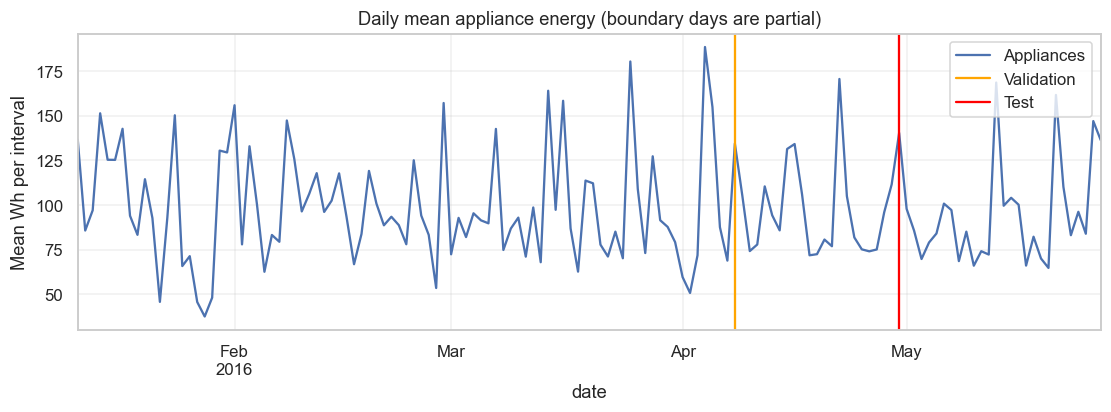

In [7]:
# Chronological splits: ~64% train / ~16% validation / ~20% test

train_end, test_start = split_boundaries(len(df))
train = df.iloc[:train_end]
audit = audit_data(df, DATA_PATH)

display(pd.Series({
    "rows": audit["rows"],
    "columns_including_date": audit["columns_including_date"],
    "start": audit["start"],
    "end": audit["end"],
    "interval_minutes": audit["interval_minutes"],
    "missing_cells": audit["missing_cells"],
    "duplicate_timestamps": audit["duplicate_timestamps"]
}, name="Dataset"))

fig, ax = plt.subplots(figsize=(12, 3.5))
df[TARGET].resample("D").mean().plot(ax=ax)
ax.axvline(df.index[train_end], color="orange", label="Validation")
ax.axvline(df.index[test_start], color="red", label="Test")
ax.set(ylabel="Mean Wh per interval",
       title="Daily mean appliance energy (boundary days are partial)")
ax.legend()
plt.show()


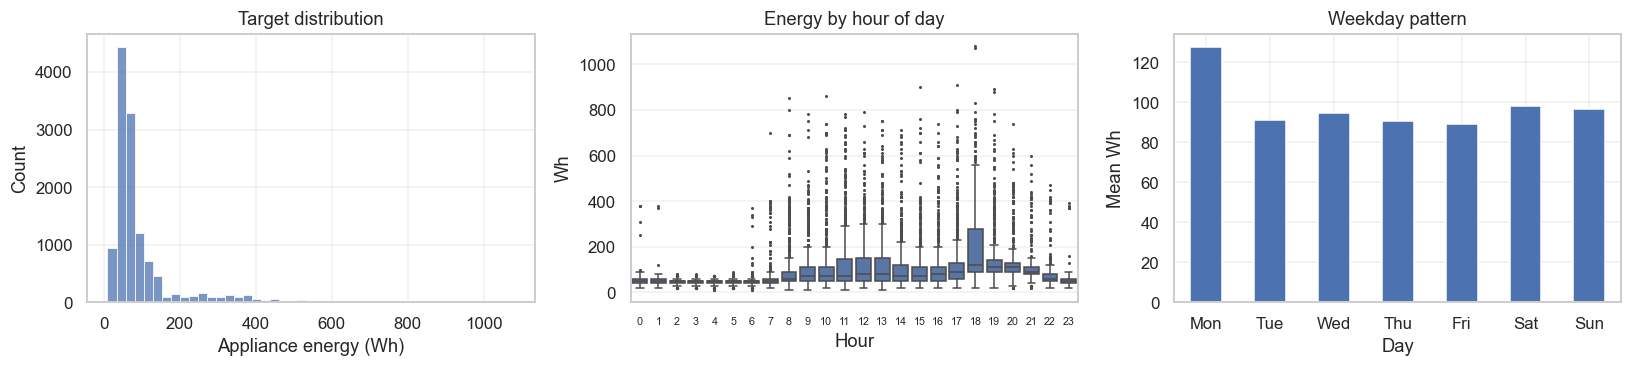

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))

sns.histplot(train[TARGET], bins=45, ax=axes[0])
axes[0].set(xlabel="Appliance energy (Wh)", title="Target distribution")

sns.boxplot(x=train.index.hour, y=train[TARGET].to_numpy(),
            ax=axes[1], fliersize=1)
axes[1].set(xlabel="Hour", ylabel="Wh", title="Energy by hour of day")
axes[1].tick_params(axis="x", labelsize=7)

train[TARGET].groupby(train.index.dayofweek).mean().plot.bar(ax=axes[2])
axes[2].set_xticklabels(
    ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"], rotation=0)
axes[2].set(xlabel="Day", ylabel="Mean Wh", title="Weekday pattern")

plt.tight_layout()
plt.show()


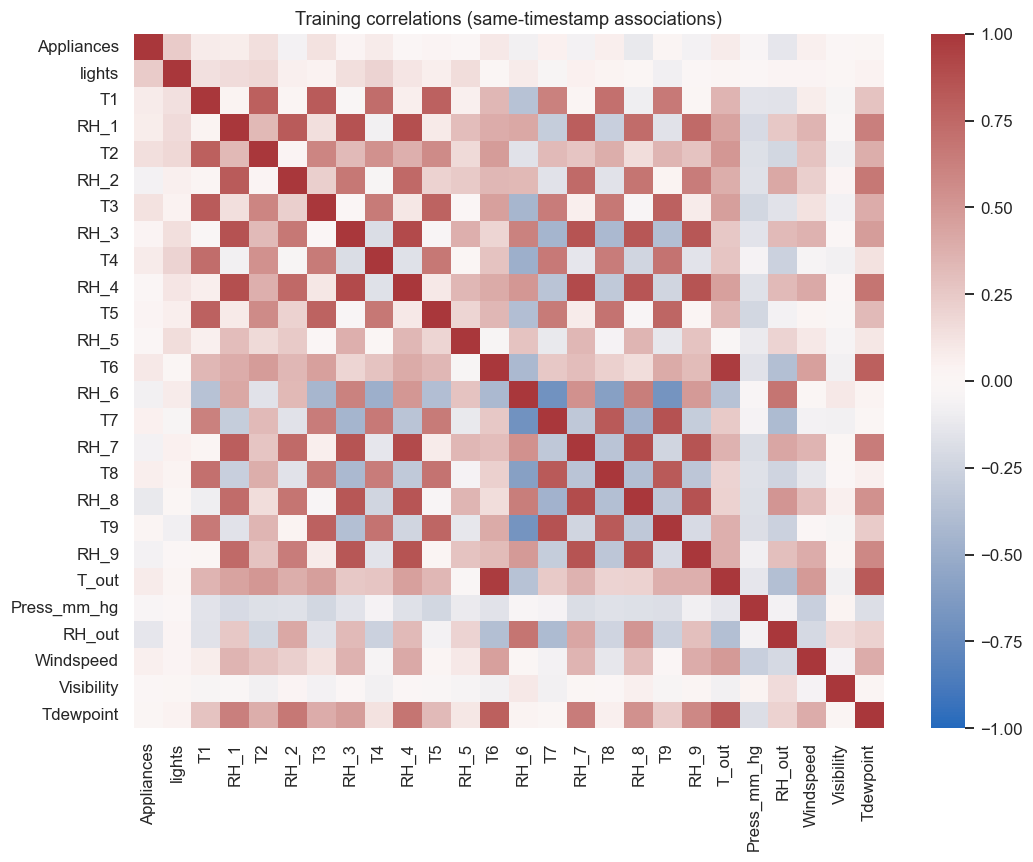

In [9]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(train.corr(), cmap="vlag", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Training correlations (same-timestamp associations)")
plt.tight_layout()
plt.show()


In [10]:
hourly = train[TARGET].groupby(train.index.hour).mean()
display(Markdown(
    f"Training energy is right-skewed: median **{train[TARGET].median():.0f} Wh**, "
    f"mean **{train[TARGET].mean():.1f} Wh** and maximum **{train[TARGET].max():.0f} Wh**. "
    f"Mean demand is highest at **{hourly.idxmax():02d}:00** and lowest at "
    f"**{hourly.idxmin():02d}:00**. Room measurements are correlated, so feature selection "
    "can reduce redundancy. These associations do not establish causality."
))


Training energy is right-skewed: median **60 Wh**, mean **98.2 Wh** and maximum **1080 Wh**. Mean demand is highest at **18:00** and lowest at **03:00**. Room measurements are correlated, so feature selection can reduce redundancy. These associations do not establish causality.

## 2. Preprocessing

Parse and sort timestamps; require a regular 10-minute grid and unique dates.
The supplied data has no missing values. For future missing sensor readings,
use only preceding observations: forward-fill for up to one hour, then use
training medians. Reject missing target labels rather than inventing energy use.

Detect energy outliers with training IQR bounds. Retain peaks because high demand
can reflect real appliance operation; deleting them would make the task easier
without evidence of measurement error. Standardize features and the target using
training statistics only. This keeps different units comparable for Ridge and
neural-network optimization; unlike min-max scaling it does not depend on extrema.

Use approximately 64% training, 16% validation and 20% test in time order.
The first 179 targets are excluded to provide common lag and sequence history.


In [11]:
display(df.isna().sum().to_frame("Missing readings"))

q1, q3 = train[TARGET].quantile([.25, .75])
lower, upper = q1 - 1.5 * (q3 - q1), q3 + 1.5 * (q3 - q1)
flagged = (train[TARGET] < lower) | (train[TARGET] > upper)
print(f"Training IQR bounds: {lower:.0f} to {upper:.0f} Wh; "
      f"{flagged.sum()} flagged readings retained.")

splits = {"train": np.arange(WARMUP, train_end),
          "validation": np.arange(train_end, test_start),
          "test": np.arange(test_start, len(df))}

display(pd.DataFrame([
    {"split": name, "samples": len(rows),
     "first_target": df.index[rows[0]],
     "last_target": df.index[rows[-1]]}
    for name, rows in splits.items()
]))


,Missing readings
Appliances,0
lights,0
T1,0
RH_1,0
T2,0
RH_2,0
T3,0
RH_3,0
T4,0
RH_4,0


Training IQR bounds: -25 to 175 Wh; 1464 flagged readings retained.


,split,samples,first_target,last_target
0,train,12451,2016-01-12 22:50:00,2016-04-08 09:50:00
1,validation,3158,2016-04-08 10:00:00,2016-04-30 08:10:00
2,test,3947,2016-04-30 08:20:00,2016-05-27 18:00:00


## 3. Feature Engineering

A feature row at time *t* predicts energy at *t*, using measurements through
*t − 1* and the calendar at *t*. Rolling statistics are shifted before aggregation.

| Features | Reason |
| --- | --- |
| Past energy at 10/30 minutes, 1/3 hours and 1 day | Recent persistence and repeated daily use |
| Two extra lags chosen by training autocorrelation | Capture strong short-term dependence; a heuristic, not a claim of global optimality |
| Past 1/3-hour mean, standard deviation, maximum and recent changes | Consumption level, variability and changes |
| Hour, day, month, seconds since midnight, weekend and cyclic encodings | Calendar and daily/weekly cycles |
| Previous lighting, temperature and humidity readings | Available environmental measurements |
| Indoor/outdoor differences, temperature × humidity, evening lighting | Environmental and occupancy-related interactions |

Exclude rv1/rv2 (random, identical here) and interpolated airport weather whose
real-time availability is unclear. Retain local outdoor T6/RH_6. No holiday data
is added because occupancy and event labels are unavailable.


Selected lags (10-minute steps): [1, 2, 3, 4, 6, 18, 144]


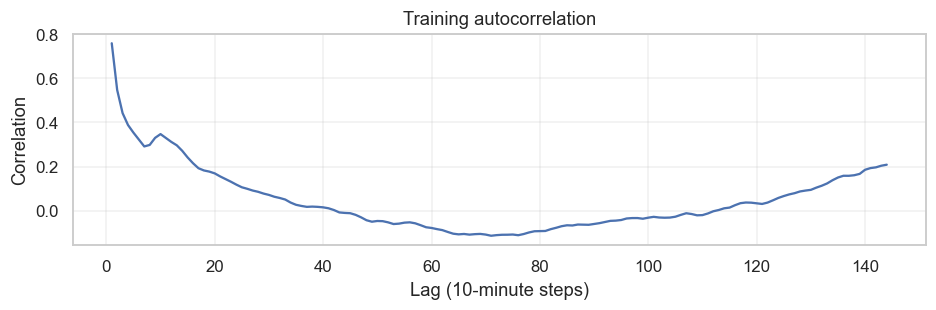

,lights_lag1,T1_lag1,RH_1_lag1,T2_lag1,RH_2_lag1,T3_lag1,RH_3_lag1,T4_lag1,RH_4_lag1,T5_lag1,...,hour_cos,dow_sin,dow_cos,indoor_temp_mean,indoor_rh_mean,indoor_outdoor_temp_gap,indoor_outdoor_rh_gap,kitchen_temp_x_rh,living_temp_x_rh,lights_x_evening
date,,,,,,,,,,,,,,,,,,,,,
2016-01-12 22:50:00,0.0,19.666667,43.0,18.89,42.410625,19.79,44.290000,19.200000,43.230000,17.390000,...,0.953717,0.974928,-0.222521,18.537917,44.913333,13.347917,-48.720000,8.456667,8.011367,0.0
2016-01-12 23:00:00,0.0,19.600000,43.0,18.89,42.500000,19.79,44.433333,19.200000,43.363333,17.390000,...,0.965926,0.974928,-0.222521,18.530152,45.090341,13.257652,-47.379659,8.428000,8.028250,0.0
2016-01-12 23:10:00,0.0,19.600000,43.0,18.89,42.645000,19.79,44.500000,19.133333,43.400000,17.356667,...,0.976296,0.974928,-0.222521,18.531198,45.233281,13.164531,-45.566719,8.428000,8.055641,0.0


Scaled feature shape: (19735, 50) | All finite: True


In [12]:
lags, acf = choose_lags(train[TARGET])
features = make_features(df, lags)
print("Selected lags (10-minute steps):", lags)

ax = acf.plot(figsize=(10, 2.5), title="Training autocorrelation")
ax.set(xlabel="Lag (10-minute steps)", ylabel="Correlation")
plt.show()

display(features.iloc[WARMUP:WARMUP + 3])

all_x, imputer, x_scaler = fit_feature_preprocessing(features, train_end, MAX_LAG)
y = df[TARGET].to_numpy(dtype=np.float32)
y_scaler = StandardScaler().fit(y[splits["train"], None])
y_scaled = y_scaler.transform(y[:, None]).ravel().astype(np.float32)
print("Scaled feature shape:", all_x.shape,
      "| All finite:", np.isfinite(all_x).all())


## 4. Feature Selection

Rank features with ExtraTrees fitted only on training rows. Keep the top 24 plus
a small fixed core of recent energy, time-of-day and weekend features. The core
preserves meaningful temporal inputs even when importance is spread across
correlated variables. Impurity importance can favor correlated predictors, so
compare Random Forest with all features against the selected subset.


,Training importance
energy_lag_1,0.381417
energy_max_6,0.095260
energy_change_10m,0.083295
energy_change_30m,0.063946
energy_mean_6,0.063934
energy_std_6,0.042130
energy_lag_2,0.039664
energy_max_18,0.035170
energy_std_18,0.018000
energy_mean_18,0.008958


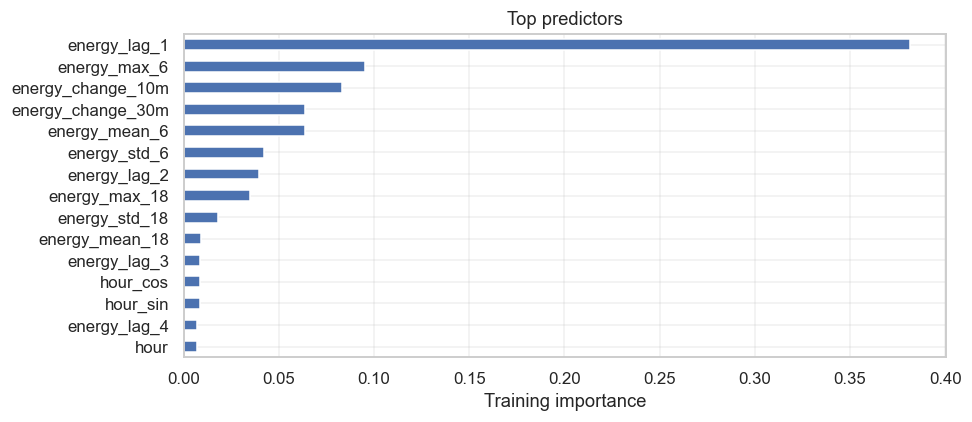

In [13]:
ranker = ExtraTreesRegressor(
    n_estimators=128, min_samples_leaf=5,
    random_state=settings["seed"], n_jobs=settings["threads"])
ranker.fit(all_x[splits["train"]], y[splits["train"]])

importance = pd.Series(ranker.feature_importances_, index=features.columns)
selected_features = select_features(importance, settings["top_k"])
x = all_x[:, [features.columns.get_loc(name) for name in selected_features]]

display(importance.loc[selected_features]
        .sort_values(ascending=False)
        .to_frame("Training importance"))

ax = importance.sort_values().tail(15).plot.barh(figsize=(9, 4))
ax.set(xlabel="Training importance", title="Top predictors")
plt.tight_layout()
plt.show()


## 5. Model Design

Baselines are persistence, daily seasonality, Ridge regression and Random Forest.
Ridge gives a regularized linear benchmark; Random Forest captures nonlinear
relationships. LSTM and GRU use gated memory to model ordered feature sequences.

Each network uses one or two recurrent layers with 32 or 64 units, followed by
dropout, a 16-unit ReLU layer and a linear scalar output. Recurrent cells use their
standard sigmoid/tanh gates. A linear head supports regression on standardized
energy. Predictions are converted back to Wh and clipped at zero for every
learned model.

AdamW uses adaptive learning rates with weight decay (`1e-4`). MSE emphasizes
larger errors. Dropout, weight decay, gradient clipping (`1.0`) and early stopping
limit overfitting or unstable updates. Training uses chronological batches.


In [14]:
display(pd.DataFrame(settings["trials"]))

trial = settings["trials"][0]
model = EnergyRNN(
    x.shape[1],
    **{key: trial[key] for key in ["kind", "hidden", "layers", "dropout"]})
sequence, target = SequenceDataset(
    x, y_scaled, splits["train"], trial["lookback"])[0]

print(model)
print("Sequence shape:", tuple(sequence.shape),
      "| Parameters:", sum(p.numel() for p in model.parameters()))


,name,kind,hidden,layers,dropout,lr,batch_size,lookback
0,LSTM_initial,LSTM,32,1,0.1,0.0010,128,18
1,GRU_initial,GRU,32,1,0.1,0.0010,128,18
2,LSTM_tuned,LSTM,64,1,0.2,0.0005,64,36
3,GRU_tuned,GRU,64,2,0.2,0.0005,128,36


EnergyRNN(
  (rnn): LSTM(25, 32, batch_first=True)
  (head): Sequential(
    (0): Dropout(p=0.1, inplace=False)
    (1): Linear(in_features=32, out_features=16, bias=True)
    (2): ReLU()
    (3): Linear(in_features=16, out_features=1, bias=True)
  )
)
Sequence shape: (18, 25) | Parameters: 8097


## 6. Training and Optimisation

Evaluate four predeclared configurations (two per architecture) covering history
length, units, layers, dropout, learning rate and batch size. This is a small
manual search, not an exhaustive grid. Stop after five epochs without improved
validation MSE, up to 25 epochs, and restore the best checkpoint.

Select the deep model by validation RMSE in Wh, then evaluate the fixed candidates
on test. Test scores do not choose hyperparameters. The cell below either runs
this experiment or loads the included results.


,name,kind,hidden,layers,dropout,lr,batch_size,lookback,best_epoch,epochs_run,parameters,MAE_Wh,RMSE_Wh,R2,MAPE_pct
0,LSTM_initial,LSTM,32,1,0.1,0.001,128,18,15,20,8097,26.679,60.064,0.624,24.699
1,GRU_initial,GRU,32,1,0.1,0.001,128,18,11,16,6209,27.036,61.374,0.607,24.601
2,LSTM_tuned,LSTM,64,1,0.2,0.000,64,36,13,18,24353,27.028,61.221,0.609,24.172
3,GRU_tuned,GRU,64,2,0.2,0.000,128,36,9,14,43489,26.888,61.444,0.606,23.847


,model,MAE_Wh,RMSE_Wh,R2,MAPE_pct
0,Persistence,27.609,69.646,0.494,22.393
1,Daily_seasonal,56.191,119.693,-0.494,54.126
2,Ridge,27.661,62.869,0.588,25.039
3,RandomForest_selected,27.211,58.500,0.643,25.877
4,RandomForest_all,32.671,61.799,0.602,32.308
5,LSTM_initial,26.679,60.064,0.624,24.699
6,GRU_initial,27.036,61.374,0.607,24.601
7,LSTM_tuned,27.028,61.221,0.609,24.172
8,GRU_tuned,26.888,61.444,0.606,23.847


Selected deep model: LSTM_initial
Overall validation winner: RandomForest_selected


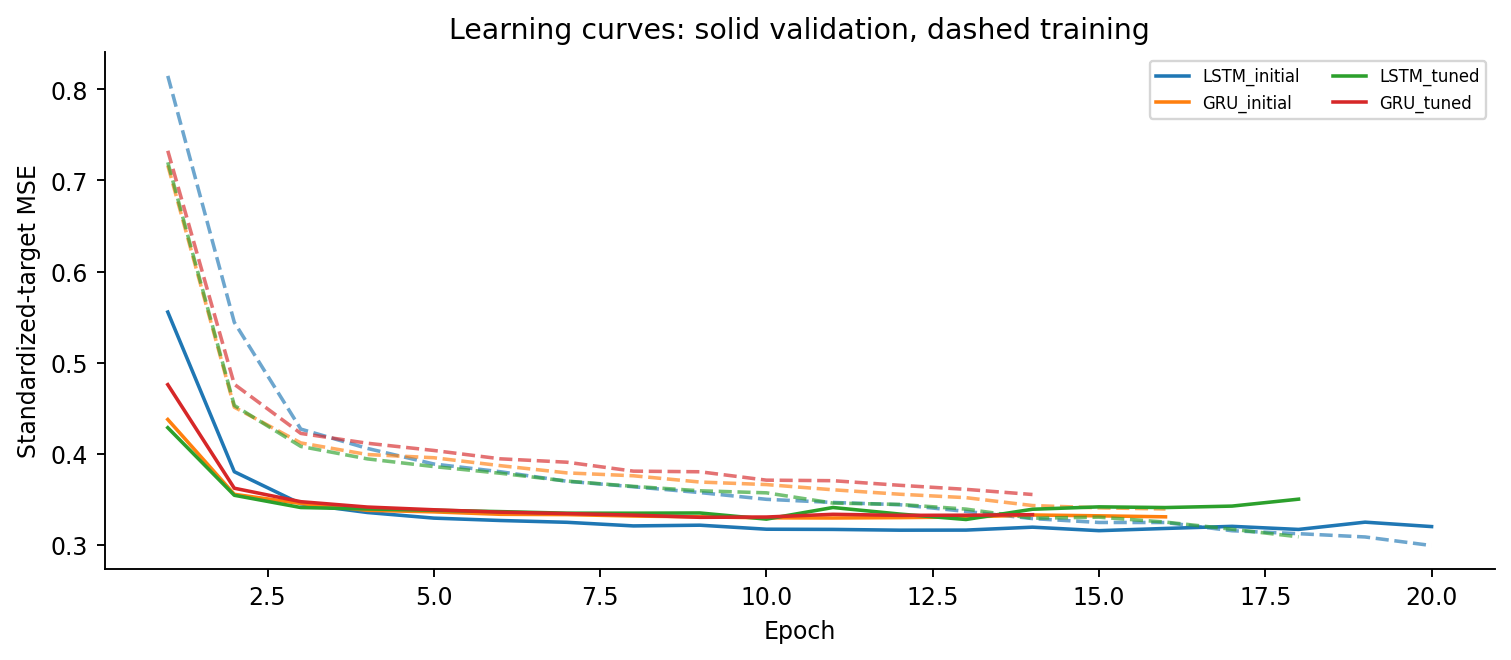

In [15]:
if RUN_TRAINING:
    run_pipeline(DATA_PATH, ROOT / "configs/assessment.json", RESULT_ROOT)

reports = RESULT_ROOT / "reports"
summary = json.loads((reports / "run_summary.json").read_text())
if (summary["source_sha256"] != audit["source_sha256"]
        or summary["settings"] != settings):
    raise ValueError(
        "Saved results do not match this dataset/configuration; "
        "run training in a new directory.")

selection = json.loads(
    (reports / "selection_frozen_before_test.json").read_text())
validation = pd.read_csv(reports / "validation_metrics.csv")
tuning = pd.read_csv(reports / "tuning_results.csv")

display(tuning.drop(columns=["seconds"]).round(3))
display(validation.round(3))
print("Selected deep model:", selection["selected_deep_model"])
print("Overall validation winner:", selection["overall_validation_champion"])
display(Image(filename=str(reports / "figures/09_learning_curves.png")))


In [16]:
test_metrics = pd.read_csv(reports / "test_metrics.csv")
comparison = (validation[["model", "RMSE_Wh"]]
              .rename(columns={"RMSE_Wh": "validation_RMSE_Wh"}))
comparison = comparison.merge(
    test_metrics[["model", "MAE_Wh", "RMSE_Wh"]], on="model")
comparison = comparison.set_index("model")

rows = []
for kind in ["LSTM", "GRU"]:
    initial = comparison.loc[f"{kind}_initial"]
    tuned = comparison.loc[f"{kind}_tuned"]
    rows.append({
        "architecture": kind,
        "validation_RMSE_change_Wh":
            tuned.validation_RMSE_Wh - initial.validation_RMSE_Wh,
        "test_RMSE_change_Wh":
            tuned.RMSE_Wh - initial.RMSE_Wh,
        "test_MAE_change_Wh":
            tuned.MAE_Wh - initial.MAE_Wh,
    })

display(pd.DataFrame(rows).round(3))
print("Change = tuned minus initial; negative means improvement.")

selected_name = selection["selected_deep_model"]
display(Markdown(
    f"The validation-selected deep model is **{selected_name}**. "
    "A test improvement alone is not a reason to replace the "
    "validation choice. Changing several settings together also "
    "prevents attributing a difference to one setting."
))


,architecture,validation_RMSE_change_Wh,test_RMSE_change_Wh,test_MAE_change_Wh
0,LSTM,1.157,2.193,1.057
1,GRU,0.069,-1.134,-0.035


Change = tuned minus initial; negative means improvement.


The validation-selected deep model is **LSTM_initial**. A test improvement alone is not a reason to replace the validation choice. Changing several settings together also prevents attributing a difference to one setting.

## 7. Results

MAE and RMSE are measured in Wh; lower is better. R² measures explained variance,
and MAPE is supplementary because small energy values can inflate percentages.
All models predict the same test timestamps. Evaluation is rolling one-step:
earlier test readings become available before later forecasts; model weights stay
fixed. These are not forecasts for an entire day made at a single starting time.


,model,MAE_Wh,RMSE_Wh,R2,MAPE_pct
0,Persistence,26.651,66.438,0.467,21.936
1,Daily_seasonal,53.679,112.177,-0.518,51.054
2,Ridge,26.643,60.050,0.565,23.597
3,RandomForest_selected,28.923,58.832,0.582,27.827
4,RandomForest_all,43.764,69.836,0.412,45.348
5,LSTM_initial,26.831,59.070,0.579,24.654
6,GRU_initial,25.757,59.808,0.568,22.018
7,LSTM_tuned,27.888,61.263,0.547,25.558
8,GRU_tuned,25.722,58.675,0.585,22.723


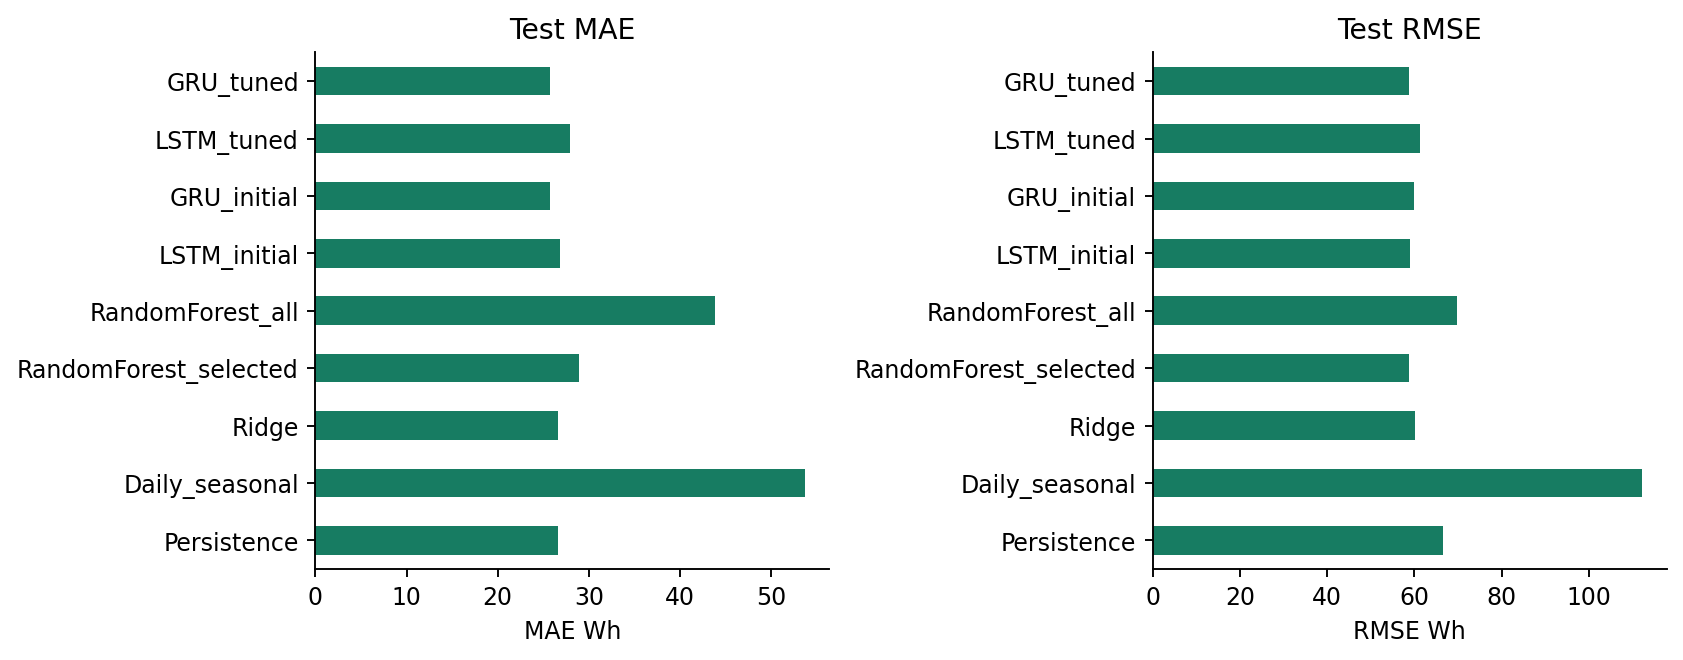

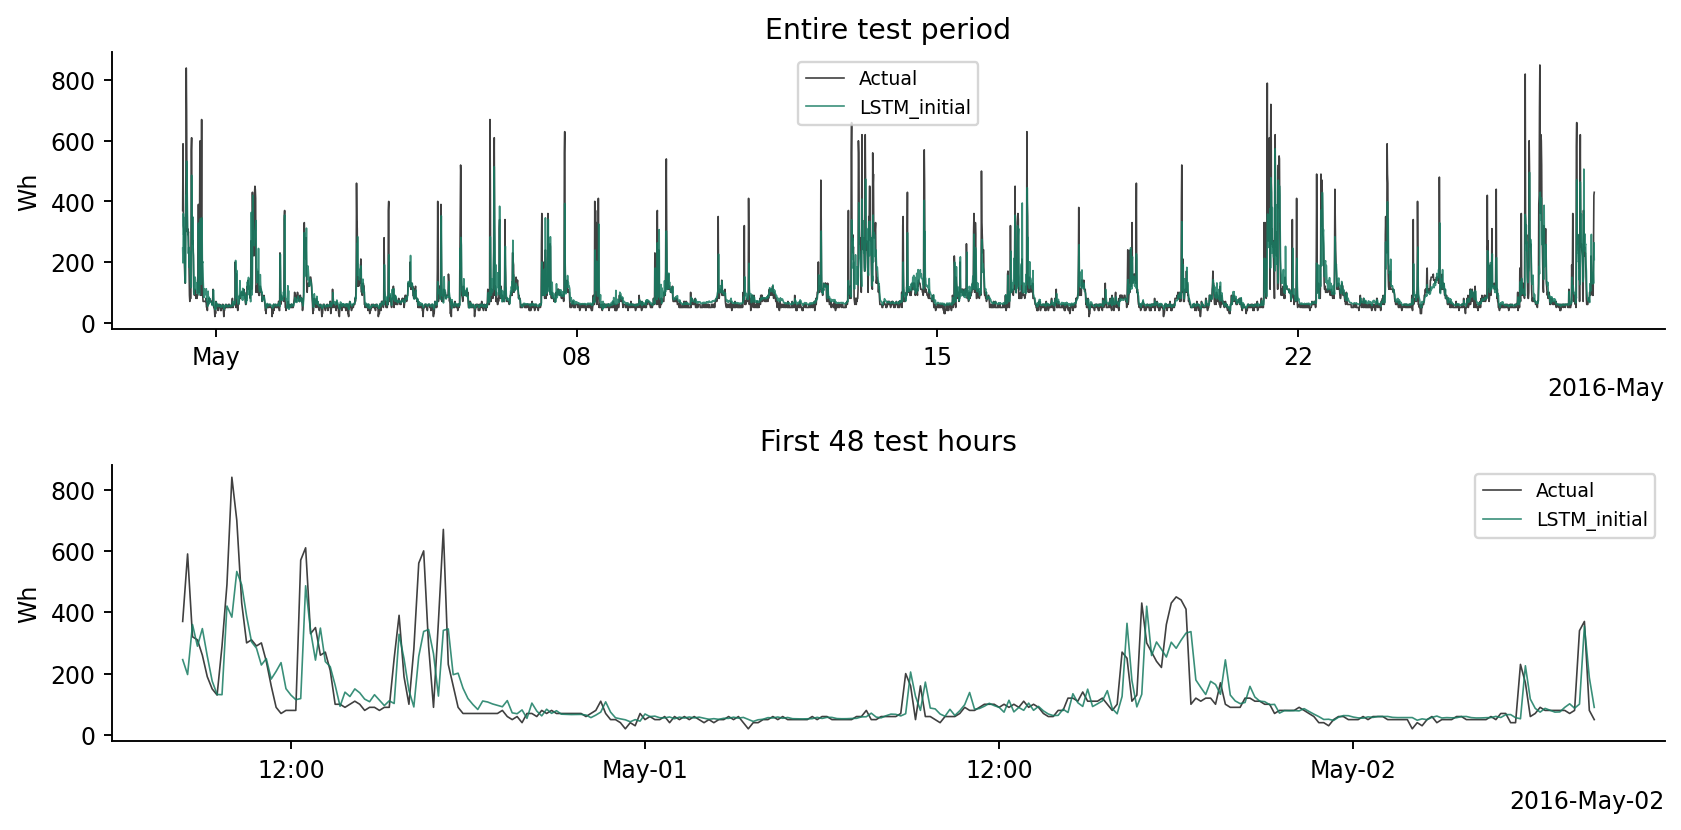

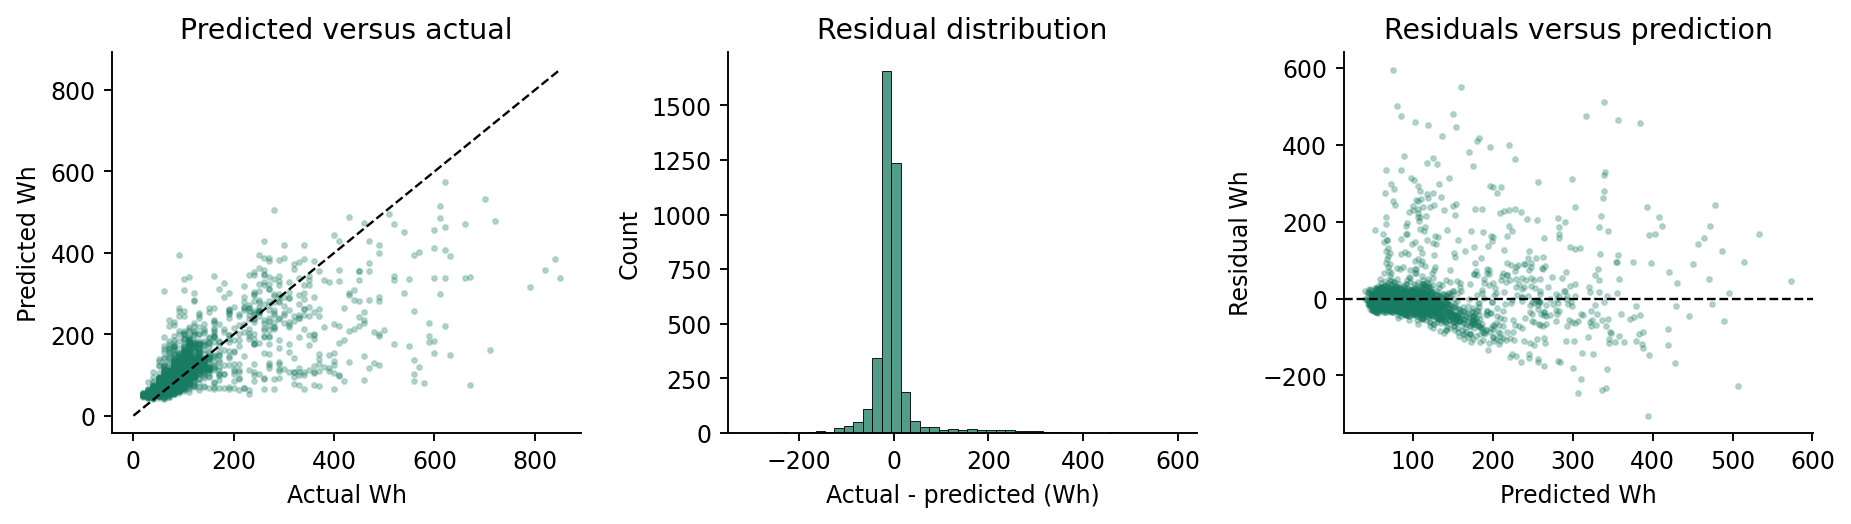

,slice,threshold_Wh,samples,MAE_Wh,RMSE_Wh,R2,MAPE_pct
0,below_training_p95,340.0,3804,19.691,34.668,0.532,23.889
1,at_or_above_training_p95,340.0,143,216.758,253.652,-3.740,45.022


In [17]:
display(test_metrics.round(3))

for filename in ["06_metric_comparison.png",
                 "07_predictions.png",
                 "08_residuals.png"]:
    display(Image(filename=str(reports / "figures" / filename)))

peak_errors = pd.read_csv(reports / "peak_error_analysis.csv")
display(peak_errors.round(3))


In [18]:
metrics = test_metrics.set_index("model")
chosen = metrics.loc[selected_name]
gain = 100 * (1 - chosen.RMSE_Wh / metrics.loc["Persistence", "RMSE_Wh"])
champion = selection["overall_validation_champion"]

display(Markdown(
    f"**{selected_name}** has test MAE **{chosen.MAE_Wh:.2f} Wh** and RMSE "
    f"**{chosen.RMSE_Wh:.2f} Wh**, a **{gain:.1f}%** RMSE reduction relative "
    f"to persistence. The overall validation winner, **{champion}**, has test "
    f"RMSE **{metrics.loc[champion, 'RMSE_Wh']:.2f} Wh**. "
    "The residual plots and peak-demand table show where errors remain. "
    "Positive residuals indicate underprediction."
))

display(forecast_next(DATA_PATH, RESULT_ROOT))


**LSTM_initial** has test MAE **26.83 Wh** and RMSE **59.07 Wh**, a **11.1%** RMSE reduction relative to persistence. The overall validation winner, **RandomForest_selected**, has test RMSE **58.83 Wh**. The residual plots and peak-demand table show where errors remain. Positive residuals indicate underprediction.

{'forecast_timestamp': '2016-05-27 18:10:00',
 'predicted_energy_Wh': 218.10916073927748,
 'model': 'LSTM_initial',
 'horizon_minutes': 10,
 'note': 'Point forecast; actual next reading is not supplied or known.'}

## 8. Challenges and Conclusion

- **Temporal leakage:** shift measured inputs before creating rolling features;
  fit imputation, scaling and feature ranking only on training data.
- **Demand peaks:** retain plausible high readings and report errors separately
  above the training 95th percentile. Sparse peaks remain difficult to predict.
- **Model complexity:** compare compact and larger recurrent candidates and retain
  the validation winner. Larger models are not automatically better.

Recent energy readings provide a strong baseline. The recorded comparison above
shows whether recurrent models add value over persistence and Random Forest.
The result applies to one household and one held-out period. Future work could
use expanding-window validation within development data and occupancy measurements;
any further tuning needs a fresh final holdout. The next-timestamp prediction is
an estimate without an observed target in this file.


## 9. References

- Supplied *Deep Learning AI Assessment.pdf*: assessment tasks and report requirements.
- Candanedo, L. (2017). [Appliances Energy Prediction](https://archive.ics.uci.edu/dataset/374/appliances+energy+prediction),
  UCI Machine Learning Repository. [DOI: 10.24432/C5VC8G](https://doi.org/10.24432/C5VC8G), CC BY 4.0.
  The supplied raw CSV is unchanged; transformations are described above.
- [scikit-learn: avoiding data leakage](https://scikit-learn.org/stable/common_pitfalls.html).
- PyTorch recurrent layers: [LSTM](https://docs.pytorch.org/docs/stable/generated/torch.nn.LSTM.html)
  and [GRU](https://docs.pytorch.org/docs/stable/generated/torch.nn.GRU.html).
